<a href="https://colab.research.google.com/github/Tolureis/CMPE-460-Deep-Learning/blob/main/Bias_Variance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-1126702717.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x[i] = np.random.uniform(i/n_data, (i+1)/n_data, 1)
/tmp/ipython-input-1126702717.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y[i] = true_function(x[i]) + np.random.normal(0, sigma_y, 1)


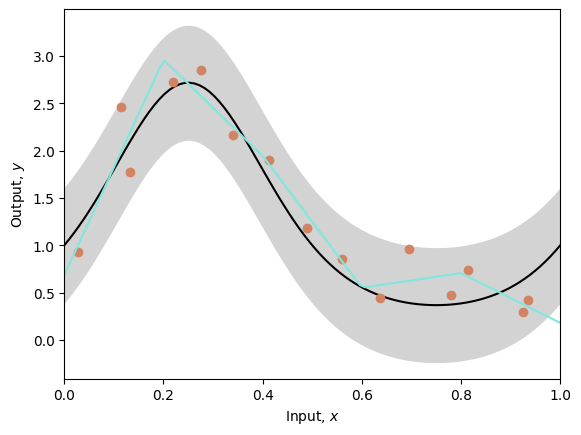

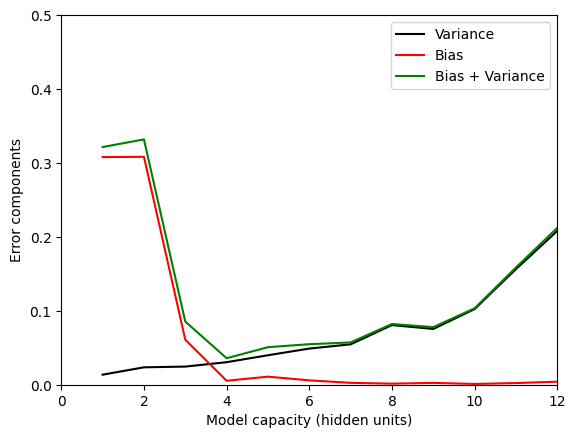

In [ ]:
# -*- coding: utf-8 -*-
"""
8_2_Bias_Variance_Trade_Off.py
Completed version with English comments
"""

import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 1. TRUE FUNCTION AND DATA GENERATION
# ==============================

def true_function(x):
    y = np.exp(np.sin(x*(2*np.pi)))
    return y

def generate_data(n_data, sigma_y=0.3):
    x = np.ones(n_data)
    for i in range(n_data):
        x[i] = np.random.uniform(i/n_data, (i+1)/n_data, 1)

    y = np.ones(n_data)
    for i in range(n_data):
        y[i] = true_function(x[i]) + np.random.normal(0, sigma_y, 1)
    return x, y

def plot_function(x_func, y_func, x_data=None, y_data=None, x_model=None, y_model=None, sigma_func=None, sigma_model=None):
    fig, ax = plt.subplots()
    ax.plot(x_func, y_func, 'k-')
    if sigma_func is not None:
        ax.fill_between(x_func, y_func-2*sigma_func, y_func+2*sigma_func, color='lightgray')
    if x_data is not None:
        ax.plot(x_data, y_data, 'o', color='#d18362')
    if x_model is not None:
        ax.plot(x_model, y_model, '-', color='#7fe7de')
    if sigma_model is not None:
        ax.fill_between(x_model, y_model-2*sigma_model, y_model+2*sigma_model, color='lightgray')
    ax.set_xlim(0,1)
    ax.set_xlabel('Input, $x$')
    ax.set_ylabel('Output, $y$')
    plt.show()

# ==============================
# 2. MODEL AND TRAINING FUNCTIONS
# ==============================

def network(x, beta, omega):
    n_hidden = omega.shape[0]
    y = np.zeros_like(x)
    for c_hidden in range(n_hidden):
        line_vals = x - c_hidden/n_hidden
        h = line_vals * (line_vals > 0)
        y += omega[c_hidden] * h
    y += beta
    return y

def fit_model_closed_form(x, y, n_hidden):
    n_data = len(x)
    A = np.ones((n_data, n_hidden+1))
    for i in range(n_data):
        for j in range(1, n_hidden+1):
            A[i,j] = x[i] - (j-1)/n_hidden
            if A[i,j] < 0:
                A[i,j] = 0
    beta_omega = np.linalg.lstsq(A, y, rcond=None)[0]
    beta = beta_omega[0]
    omega = beta_omega[1:]
    return beta, omega

# ==============================
# 3. MODEL MEAN AND VARIANCE COMPUTATION
# ==============================

x_model = np.linspace(0, 1, 100)
y_func = true_function(x_model)

def get_model_mean_variance(n_data, n_datasets, n_hidden, sigma_func):
    y_model_all = np.zeros((n_datasets, x_model.shape[0]))
    for c_dataset in range(n_datasets):
        # Generate dataset
        x_data, y_data = generate_data(n_data, sigma_func)

        # Fit model
        beta, omega = fit_model_closed_form(x_data, y_data, n_hidden)

        # Evaluate model
        y_model = network(x_model, beta, omega)

        y_model_all[c_dataset, :] = y_model

    mean_model = np.mean(y_model_all, axis=0)
    std_model = np.std(y_model_all, axis=0)
    return mean_model, std_model

# ==============================
# 4. SINGLE MODEL DEMO
# ==============================

n_data = 15
sigma_func = 0.3
n_hidden = 5
np.random.seed(1)

x_data, y_data = generate_data(n_data, sigma_func)
beta, omega = fit_model_closed_form(x_data, y_data, n_hidden)
y_model = network(x_model, beta, omega)

plot_function(x_model, y_func, x_data, y_data, x_model, y_model, sigma_func=sigma_func)

# ==============================
# 5. BIAS-VARIANCE ANALYSIS
# ==============================

n_datasets = 100
hidden_variables = list(range(1, 13))
bias = np.zeros((len(hidden_variables),1))
variance = np.zeros((len(hidden_variables),1))

np.random.seed(1)
for c_hidden in range(len(hidden_variables)):
    mean_model, std_model = get_model_mean_variance(n_data, n_datasets, hidden_variables[c_hidden], sigma_func)

    # Variance: average of model variance (mean of std^2)
    variance[c_hidden] = np.mean(std_model**2)

    # Bias: mean squared difference between true and average model
    bias[c_hidden] = np.mean((mean_model - y_func)**2)

# ==============================
# 6. PLOT RESULTS
# ==============================

fig, ax = plt.subplots()
ax.plot(hidden_variables, variance, 'k-', label='Variance')
ax.plot(hidden_variables, bias, 'r-', label='Bias')
ax.plot(hidden_variables, variance+bias, 'g-', label='Bias + Variance')
ax.set_xlim(0, max(hidden_variables))
ax.set_ylim(0, 0.5)
ax.set_xlabel("Model capacity (hidden units)")
ax.set_ylabel("Error components")
ax.legend()
plt.show()